<a href="https://colab.research.google.com/github/thaisNY/Analise-Dados-Spotify-Projeto-Final-PretaLab/blob/main/Thais_Rodrigues_Projeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciclo 15 - Projeto Final — Análise Exploratória de Músicas do Spotify- Thais Rodrigues

## Objetivo

Analisar as características sonoras que diferenciam "Hits" e faixas de baixa popularidade no Spotify. O foco será investigar se os sucessos atuais tendem a ser mais curtos, mais dançantes e mais intensos (loudness) do que o resto do catálogo.

## Justificativa
Hoje em dia, com o sucesso do TikTok e dos vídeos curtos, parece que as pessoas estão com menos paciência e querem músicas que vão direto ao ponto. Escolhi analisar a "anatomia de um hit" para descobrir se os dados do Spotify provam isso. A ideia é entender se as músicas que estão no topo das paradas são realmente mais curtas, mais agitadas e com um volume mais alto do que as músicas que não fazem sucesso.

Dataset Spotify: https://drive.google.com/file/d/1G1TKSidyKCrPfLMike1ECPRG4JiBEvEr/view?usp=sharing

## Etapas do Projeto

### 1. Importação e exploração inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid", palette="pastel")

# Carregar o dataset
df = pd.read_csv("spotify_dataset.csv", index_col=0)

# Inspeção Básica
print(f"O dataset original possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset original possui 114000 linhas e 20 colunas.


In [ ]:
# Descobrir os gêneros musicais presentes
generos_unicos = df['track_genre'].unique()

In [ ]:
#Descobrir quantos generos tem no dataset
print(f"O dataset possui um total de {len(generos_unicos)} gêneros únicos.")

O dataset possui um total de 114 gêneros únicos.


In [ ]:
#Imprimindo todos os gêneros unicos
generos_unicos = sorted(df['track_genre'].dropna().unique())
#juntando na mesma linha para ocupar menos espaco
print(', '.join(generos_unicos))

acoustic, afrobeat, alt-rock, alternative, ambient, anime, black-metal, bluegrass, blues, brazil, breakbeat, british, cantopop, chicago-house, children, chill, classical, club, comedy, country, dance, dancehall, death-metal, deep-house, detroit-techno, disco, disney, drum-and-bass, dub, dubstep, edm, electro, electronic, emo, folk, forro, french, funk, garage, german, gospel, goth, grindcore, groove, grunge, guitar, happy, hard-rock, hardcore, hardstyle, heavy-metal, hip-hop, honky-tonk, house, idm, indian, indie, indie-pop, industrial, iranian, j-dance, j-idol, j-pop, j-rock, jazz, k-pop, kids, latin, latino, malay, mandopop, metal, metalcore, minimal-techno, mpb, new-age, opera, pagode, party, piano, pop, pop-film, power-pop, progressive-house, psych-rock, punk, punk-rock, r-n-b, reggae, reggaeton, rock, rock-n-roll, rockabilly, romance, sad, salsa, samba, sertanejo, show-tunes, singer-songwriter, ska, sleep, songwriter, soul, spanish, study, swedish, synth-pop, tango, techno, trance

### 1.1 Inspeção Básica

In [ ]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [ ]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000



##Tipo de dados de cada coluna

1. popularity: Inteiro (int)
2. duration_ms: Inteiro (int)
3. danceability: Decimal (float)
4. energy: Decimal (float)
5. key: Inteiro (int)
6. loudness: Decimal (float)
7. mode: Inteiro binário (int)
8. speechiness: Decimal (float)
9. acousticness: Decimal (float)
10. instrumentalness: Decimal (float)
11. liveness: Decimal (float)
12. valence: Decimal (float)
13. tempo: Decimal (float)
14. time_signature: Inteiro (int)








### 2. Limpeza e preparação de dados

In [ ]:
# Identificar a quantidade de valores ausentes em cada coluna
print("\n--- Valores Ausentes por Coluna ---")
print(df.isnull().sum())


--- Valores Ausentes por Coluna ---
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [ ]:
# Conta a quantidade total de linhas duplicadas no dataset
print("\nTotal de linhas duplicadas:")
print(df.duplicated().sum())


Total de linhas duplicadas:
450


In [ ]:
# Removendo linhas com valores nulos
df = df.dropna()

# Removendo linhas duplicadas (mantendo apenas a primeira ocorrência)
df = df.drop_duplicates()

# Verificando o tamanho do dataset após a limpeza
print(f"\nTamanho do dataset após a limpeza: {df.shape}")


Tamanho do dataset após a limpeza: (113549, 20)


In [ ]:
#Garantindo que uma musica so vai aparecer uma vez, pq acontece da mesma musica estar listada em gêneros diferentes

# Verificando a quantidade de linhas antes do corte
print(f"Total de linhas (com músicas repetidas em vários gêneros): {df.shape[0]}")

# Removendo as duplicatas com base no ID único da música ('track_id')
# O parâmetro keep='first' (que é o padrão) garante que a primeira vez que a música aparecer, ela fica. As outras são apagadas.
df = df.drop_duplicates(subset=['track_id'])

# Verificando como ficou o nosso dataset agora, apenas com músicas únicas
print(f"Total de linhas (apenas músicas únicas): {df.shape[0]}")

Total de linhas (com músicas repetidas em vários gêneros): 113549
Total de linhas (apenas músicas únicas): 89740


In [ ]:
# Criando a coluna de duração em minutos (mais fácil de interpretar)
df['duration_min'] = df['duration_ms'] / 60000

In [ ]:
#  Separando o nosso escopo de análise:
# Grupo 1: Os grandes sucessos (Popularidade alta)
df_hits = df[df['popularity'] >= 80].copy()
df_hits['categoria'] = 'Hit (Pop >= 80)'

# Grupo 2: Músicas de baixa popularidade (para servir de comparação)
df_baixa = df[df['popularity'] <= 30].copy()
df_baixa['categoria'] = 'Baixa Pop (Pop <= 30)'

# 4. Unindo os dois grupos em um único DataFrame para facilitar os gráficos
df_analise = pd.concat([df_hits, df_baixa])

# Verificando o tamanho dos nossos grupos
print(f"Quantidade de músicas 'Hit': {len(df_hits)}")
print(f"Quantidade de músicas 'Baixa Pop': {len(df_baixa)}")

Quantidade de músicas 'Hit': 627
Quantidade de músicas 'Baixa Pop': 41653


### 3. Análise descritiva

##Perguntas Norteadoras

Duração: Os "Hits" globais são mais curtos do que as músicas menos populares, confirmando a tendência de consumo rápido da "Era do TikTok"?

Ritmo e Intensidade: Músicas de grande sucesso são mais dançantes (danceability) e barulhentas (loudness) do que as faixas que não fazem sucesso?

Músicas de muito sucesso dependem mais de letras densas e muita cantoria (alta speechiness, comum no Rap e Trap) ou focam mais na melodia e na batida?

A Pergunta: Existe um ritmo cardíaco, ou seja, um "Tempo" (Batidas Por Minuto - BPM) ideal para uma música estourar, ou os hits são totalmente imprevisíveis nesse quesito?

A Fórmula: Existe uma correlação forte entre essas características sonoras, ou seja, as músicas mais populares seguem uma "receita de bolo"?




### 4. Visualização de distribuições

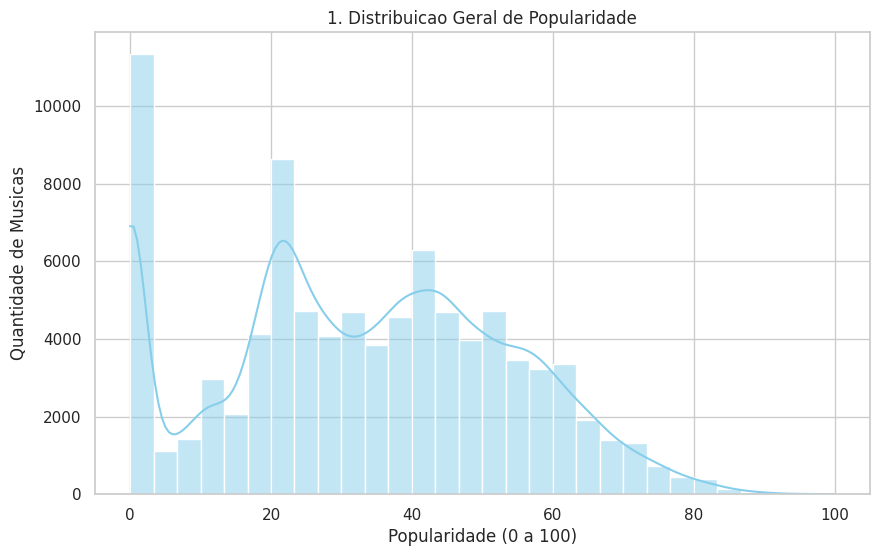

In [ ]:
# Garantindo que a duracao em minutos existe na nossa base principal
df['duration_min'] = df['duration_ms'] / 60000

# Separando as musicas de muito sucesso
df_hits = df[df['popularity'] >= 80].copy()
df_hits['categoria'] = 'Hit (Pop >= 80)'

# Separando as musicas de pouco sucesso
df_baixa = df[df['popularity'] <= 30].copy()
df_baixa['categoria'] = 'Baixa Pop (Pop <= 30)'

# Juntando os dois extremos em um dataframe so para podermos comparar depois
df_analise = pd.concat([df_hits, df_baixa])

# Define o tamanho da imagem na tela (largura, altura)
plt.figure(figsize=(10, 6))

# Cria o histograma geral. O parametro kde=True desenha a linha de curva
sns.histplot(data=df, x='popularity', bins=30, kde=True, color='skyblue')

# Define os titulos para o grafico ficar facil de entender
plt.title('1. Distribuicao Geral de Popularidade')
plt.xlabel('Popularidade (0 a 100)')
plt.ylabel('Quantidade de Musicas')

# Exibe a imagem finalizada
plt.show()

Este gráfico responde à pergunta fundamental que justifica o meu projeto: afinal, quão raro é um verdadeiro hit no Spotify? O principal insight que tirei desta visualização é que o cenário musical na plataforma é extremamente desigual. Observando a barra gigante logo no início do eixo, perto do zero, fica claro que uma quantidade massiva de músicas não tem popularidade nenhuma ou praticamente não é ouvida. Logo depois, vemos algumas ondas no meio que representam a grande massa de músicas medianas. O detalhe mais importante para o meu estudo está na ponta direita do gráfico. Conforme caminhamos para as notas mais altas, acima de 80, a linha cai drasticamente e o espaço preenchido por essas músicas de sucesso fica minúsculo. Isso me prova de forma visual e matemática que os grandes hits são uma exceção absoluta, o que justifica investigar a fundo a anatomia dessas poucas músicas especiais.

/tmp/ipykernel_5375/923804076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='categoria', y='duration_min', palette='Set2')


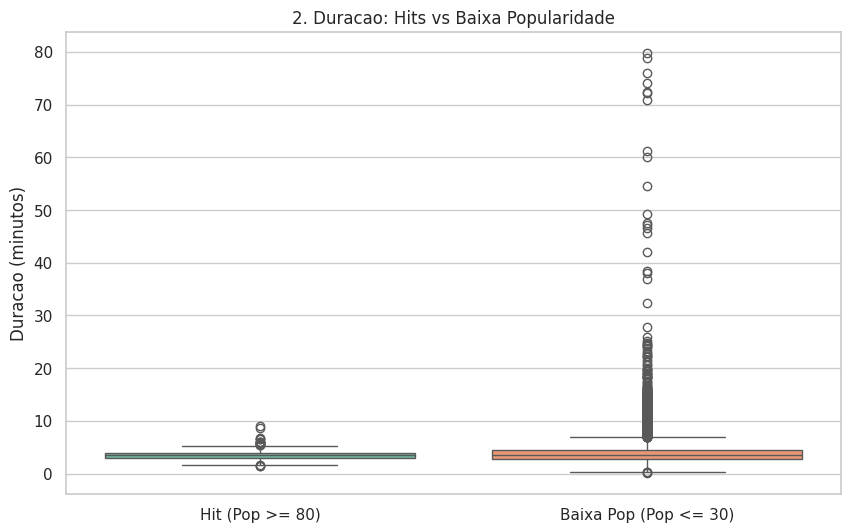

In [ ]:
# Define o tamanho da imagem na tela
plt.figure(figsize=(10, 6))

# Cria o boxplot comparativo. O eixo x separa os grupos e o eixo y mede os minutos
sns.boxplot(data=df_analise, x='categoria', y='duration_min', palette='Set2')

# Define os titulos e apaga o rotulo do eixo x para ficar mais limpo
plt.title('2. Duracao: Hits vs Baixa Popularidade')
plt.ylabel('Duracao (minutos)')
plt.xlabel('')

# Exibe a imagem finalizada
plt.show()

Este gráfico responde à minha primeira pergunta norteadora: os grandes sucessos são mais curtos, confirmando a tendência de consumo rápido da "Era do TikTok"? Observando o boxplot, a resposta é sim. O grupo de Hits (à esquerda) apresenta uma caixa bastante estreita e achatada, mostrando que a duração das músicas de alto sucesso é extremamente padronizada, girando ali em torno de 3 a 4 minutos. Existem pouquíssimos pontos fora da curva. Por outro lado, o grupo de Baixa Popularidade (à direita) possui uma dispersão gigantesca, com uma quantidade imensa de outliers (pontos soltos) representando faixas que chegam a durar 60 ou até 80 minutos. O principal insight que tiro daqui é que o tempo de atenção do ouvinte é limitado na plataforma: para ter chances de estourar no Spotify atual, a faixa não pode ter excessos de tempo, precisando ser concisa e ir direto ao ponto.

In [ ]:
#  INVESTIGANDO OS OUTLIERS: Serão podcasts ou áudio-livros?

# 1. Filtrando apenas as músicas com mais de 20 minutos
faixas_longas = df[df['duration_min'] > 20]

# 2. Selecionando apenas as colunas que importam para a nossa investigação
colunas_investigacao = ['track_name', 'artists', 'track_genre', 'duration_min', 'speechiness']
faixas_longas = faixas_longas[colunas_investigacao]

# 3. Ordenando das mais longas para as "menos" longas e mostrando as 15 maiores
resultado_investigacao = faixas_longas.sort_values(by='duration_min', ascending=False).head(15)

# Exibindo a tabela
resultado_investigacao

,track_name,artists,track_genre,duration_min,speechiness
index,,,,,
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,minimal-techno,87.288250,0.0374
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,79.817100,0.0451
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,detroit-techno,78.838367,0.0633
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,minimal-techno,76.064950,0.0612
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,chicago-house,74.125333,0.0711
13245,Live In Tokyo - Continuous Mix,Mark Farina,chicago-house,72.330433,0.0874
13195,Greenhouse Construction,Mark Farina,chicago-house,72.245350,0.0611
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,drum-and-bass,70.770100,0.0899
101390,Ocean Waves Sounds,Ocean Sounds,sleep,68.670967,0.0612


Ao investigar os outliers com mais de 20 minutos de duração, a baixa métrica de speechiness (fala) descartou nossa hipótese inicial de que seriam episódios de podcasts. Na verdade, os dados revelaram que essas faixas extremamente longas são "áudios utilitários" e gravações contínuas, dividindo-se em: sets completos de DJs (Continuous Mixes), ruídos brancos para dormir (como sons de ondas ou até 60 minutos de aspirador de pó) e longas improvisações instrumentais de meditação.

Essa descoberta mostra que o Spotify vai muito além da música comercial, funcionando também como um grande repositório de áudios de rotina. Isso explica perfeitamente a enorme variação de tempo no nosso gráfico do grupo de baixa popularidade, já que um hit atual de 3 minutos tem uma estrutura de consumo completamente diferente de uma hora ininterrupta de sons para relaxamento.

/tmp/ipykernel_5375/666737390.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_zoom, x='categoria', y='duration_min', palette='Set2')


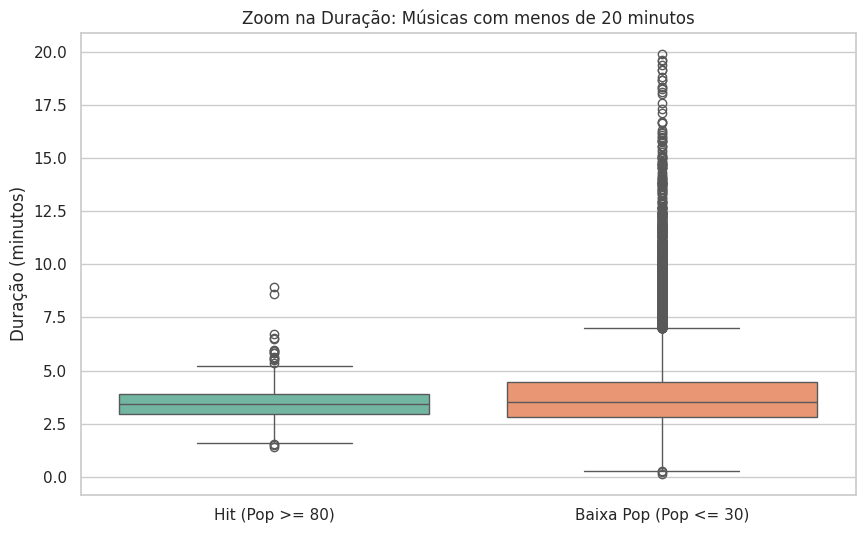

--- FICHA TÉCNICA DE TEMPO DOS HITS ---
count    627.000000
mean       3.500003
std        0.819658
min        1.422667
25%        2.950900
50%        3.428567
75%        3.886242
max        8.934433
Name: duration_min, dtype: float64


In [ ]:
# --- DANDO UM ZOOM NA DURAÇÃO ---

# 1. Filtrando para ver apenas músicas com menos de 20 minutos
df_zoom = df_analise[df_analise['duration_min'] <= 20]

# 2. Desenhando o Boxplot com Zoom
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_zoom, x='categoria', y='duration_min', palette='Set2')
plt.title('Zoom na Duração: Músicas com menos de 20 minutos')
plt.ylabel('Duração (minutos)')
plt.xlabel('')
plt.show()

# 3. Mostrando a "Ficha Técnica" do tempo dos Hits
print("--- FICHA TÉCNICA DE TEMPO DOS HITS ---")
print(df_hits['duration_min'].describe())

/tmp/ipykernel_5375/1629030963.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_zoom, x='categoria', y='duration_min', palette='Set2')


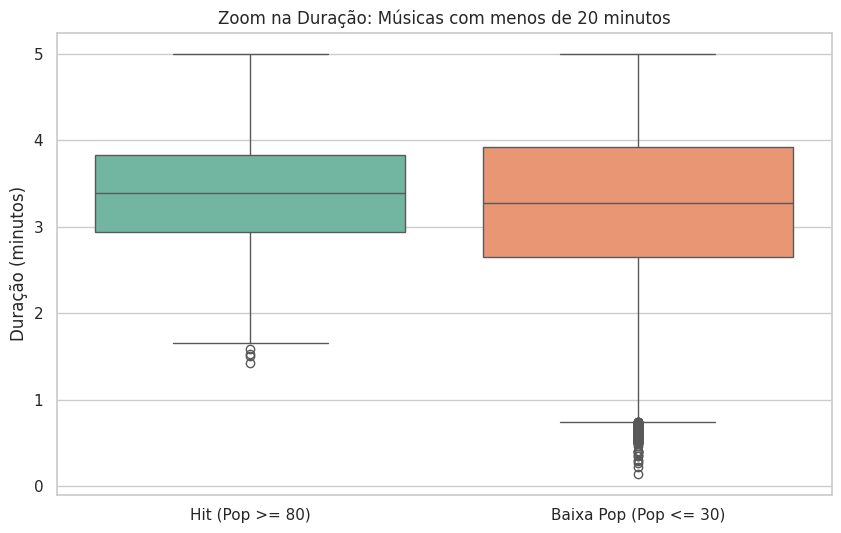

--- FICHA TÉCNICA DE TEMPO DOS HITS ---
count    627.000000
mean       3.500003
std        0.819658
min        1.422667
25%        2.950900
50%        3.428567
75%        3.886242
max        8.934433
Name: duration_min, dtype: float64


In [ ]:
# --- DANDO MAIS UM ZOOM NA DURAÇÃO ---

# 1. Filtrando para ver apenas músicas com menos de 5 minutos
df_zoom = df_analise[df_analise['duration_min'] <= 5]

# 2. Desenhando o Boxplot com Zoom
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_zoom, x='categoria', y='duration_min', palette='Set2')
plt.title('Zoom na Duração: Músicas com menos de 20 minutos')
plt.ylabel('Duração (minutos)')
plt.xlabel('')
plt.show()

# 3. Mostrando a "Ficha Técnica" do tempo dos Hits
print("--- FICHA TÉCNICA DE TEMPO DOS HITS ---")
print(df_hits['duration_min'].describe())

Ao aplicar um "zoom" limitando a análise a faixas com menos de 5 minutos, um padrão comercial fascinante se revelou. A caixa do grupo de grande sucesso (Hits) é visivelmente mais compacta do que a de baixa popularidade. Isso indica uma forte padronização da indústria: a esmagadora maioria dos hits orbita em uma janela de tempo muito estreita e segura, concentrando-se entre 3 e 4 minutos, com raríssimas exceções caindo para a casa de 1 minuto e meio. Em contraste, as faixas impopulares variam drasticamente, incluindo uma enxurrada de áudios com menos de 1 minuto (possíveis vinhetas, interlúdios ou ruídos curtos). O insight central é claro: para estourar globalmente, a faixa não pode ser nem longa demais para cansar, nem curta demais para parecer incompleta; ela precisa acertar a "janela de ouro" de retenção do ouvinte atual.

/tmp/ipykernel_5375/155586637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='categoria', y='danceability', palette='Set2')


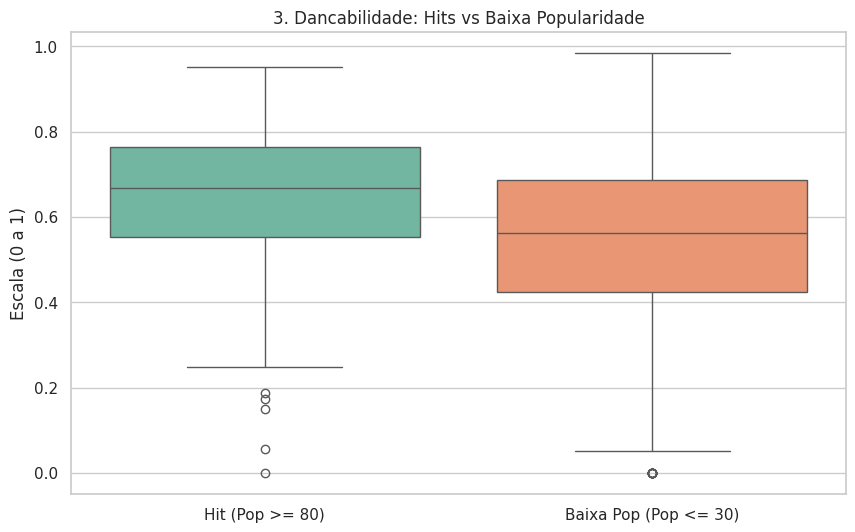

In [ ]:
# Define o tamanho da imagem na tela
plt.figure(figsize=(10, 6))

# Cria o boxplot comparativo usando a coluna de dancabilidade no eixo vertical
sns.boxplot(data=df_analise, x='categoria', y='danceability', palette='Set2')

# Adiciona os titulos adequados para a escala de dancabilidade
plt.title('3. Dancabilidade: Hits vs Baixa Popularidade')
plt.ylabel('Escala (0 a 1)')
plt.xlabel('')

# Exibe a imagem finalizada
plt.show()


Este terceiro grafico responde a nossa segunda pergunta norteadora sobre o ritmo e a intensidade das musicas de sucesso. Observando o boxplot de dancabilidade, a resposta e um sonoro sim, pois os grandes hits sao consideravelmente mais dancantes. A caixa do grupo de Hits, a esquerda, esta posicionada bem mais para cima na escala de 0 a 1, com a linha central indicando que a grande maioria dos sucessos tem uma pontuacao alta nesse quesito. Em contraste, o grupo de baixa popularidade possui uma caixa mais larga e esticada para baixo, mostrando que as faixas impopulares englobam de tudo, desde musicas muito lentas e acusticas ate as agitadas. O grande insight que tiro dessa visualizacao e que o ritmo dita o mercado atual. Em uma era impulsionada por dancas virais e consumo agil, ter uma batida marcante e ritmada e praticamente um pre-requisito preenchido pela esmagadora maioria das faixas que chegam ao topo do Spotify.

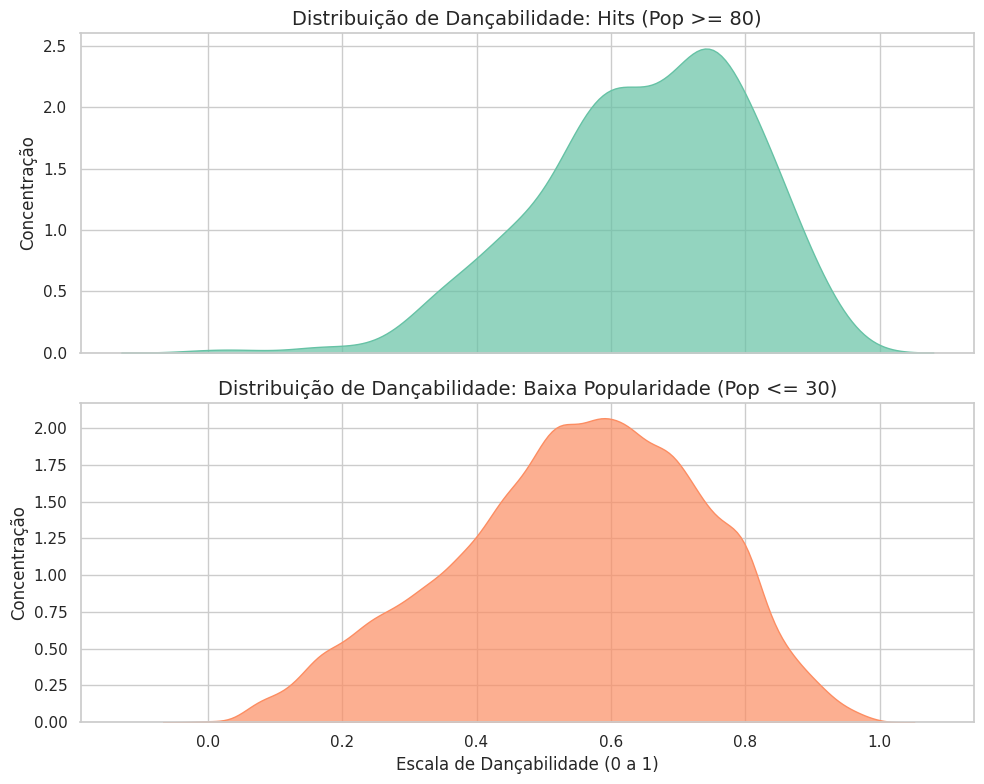

In [ ]:
# --- COMPARATIVO DE DISTRIBUIÇÃO: Hits vs Baixa Popularidade ---

# Criando a figura com dois subplots (um em cima do outro)
# sharex=True garante que a escala de 0 a 1 seja a mesma para os dois para podermos comparar
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Cores baseadas no palette Set2 que já estávamos usando
cor_hit = '#66c2a5'    # Verde água
cor_baixa = '#fc8d62'  # Laranja/Coral

# 1. Gráfico de cima: Hits
sns.kdeplot(data=df_analise[df_analise['categoria'] == 'Hit (Pop >= 80)'],
            x='danceability', fill=True, color=cor_hit, ax=axes[0], alpha=0.7)
axes[0].set_title('Distribuição de Dançabilidade: Hits (Pop >= 80)', fontsize=14)
axes[0].set_ylabel('Concentração')
axes[0].set_xlabel('')

# 2. Gráfico de baixo: Baixa Popularidade
sns.kdeplot(data=df_analise[df_analise['categoria'] == 'Baixa Pop (Pop <= 30)'],
            x='danceability', fill=True, color=cor_baixa, ax=axes[1], alpha=0.7)
axes[1].set_title('Distribuição de Dançabilidade: Baixa Popularidade (Pop <= 30)', fontsize=14)
axes[1].set_ylabel('Concentração')
axes[1].set_xlabel('Escala de Dançabilidade (0 a 1)')

# Ajustando o layout para que os títulos e eixos fiquem organizados
plt.tight_layout()
plt.show()

A "Montanha" dos Hits: Ela é alta e fina, e está muito deslocada para a direita (perto do 0.7 e 0.8). Isso mostra que quase todos os hits mundiais estão amontoados em uma zona de alta dançabilidade. É a prova visual da "fórmula do ritmo".

A "Montanha" da Baixa Popularidade: Ela é mais baixa, larga e "esparramada". Isso indica que músicas que não fazem sucesso não seguem padrão nenhum: existem muitas músicas lentas, muitas médias e algumas rápidas. Elas não têm um "foco".

/tmp/ipykernel_5375/3668682930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='categoria', y='speechiness', palette='Set2')


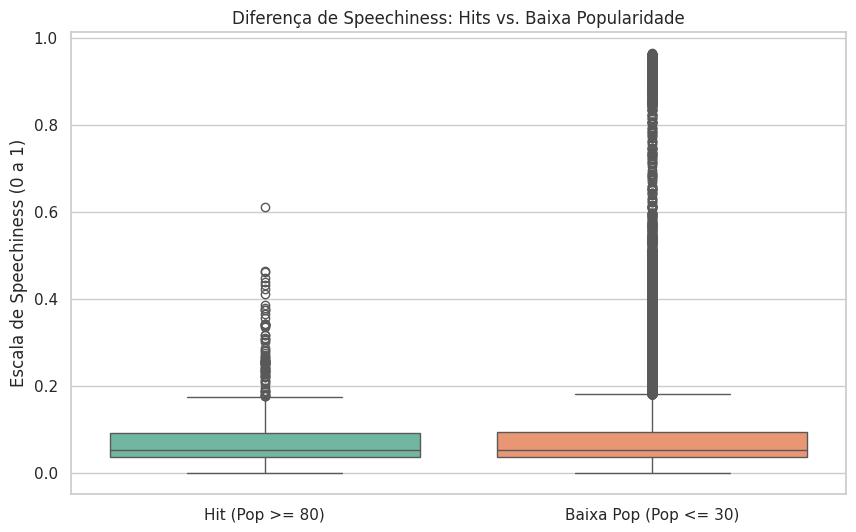

In [ ]:
# --- PROVANDO SPEECHINESS: Letras Densas vs. Melodia/Batida ---
# Objetivo: Responder se hits dependem de muita cantoria/fala.

plt.figure(figsize=(10, 6))

# Criando o boxplot comparativo
sns.boxplot(data=df_analise, x='categoria', y='speechiness', palette='Set2')

# Ajustando títulos e rótulos
plt.title('Diferença de Speechiness: Hits vs. Baixa Popularidade')
plt.ylabel('Escala de Speechiness (0 a 1)')
plt.xlabel('')

plt.show()

Este gráfico responde à minha pergunta sobre a densidade das letras (speechiness). O boxplot revela que a imensa maioria das músicas, sejam sucessos ou não, foca na melodia (valores baixos próximos a 0.05). O grande diferencial está nos pontos fora da curva: enquanto os Hits chegam no máximo a um nível moderado de fala (típico de sucessos de Rap e Trap com batidas fortes), o grupo de Baixa Popularidade está repleto de áudios puramente falados (perto de 1.0), como podcasts ou discursos. O insight é claro: para estourar no Spotify, a música não pode abrir mão da melodia; o excesso de "falatório" sem uma base musical forte é um barreira para o sucesso global.

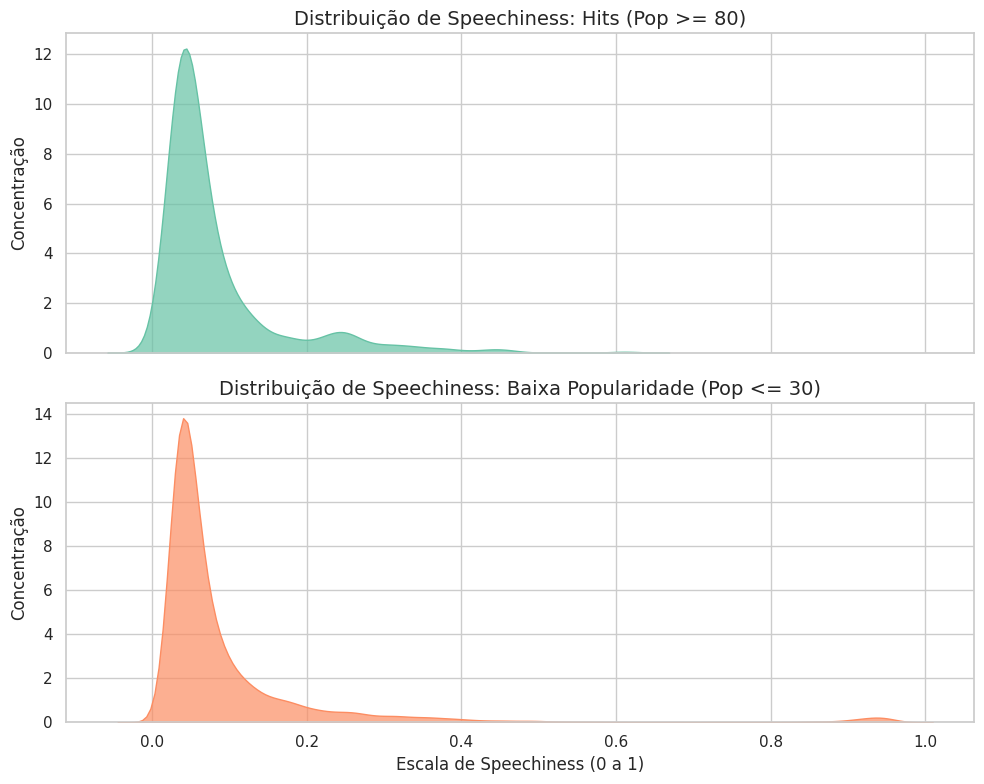

In [ ]:
# --- COMPARATIVO DE DISTRIBUIÇÃO: Speechiness (Hits vs Baixa Pop) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. CARREGANDO E PREPARANDO (Para evitar o erro de 'df not defined')
df = pd.read_csv('spotify_dataset.csv')
df_hits = df[df['popularity'] >= 80].copy()
df_hits['categoria'] = 'Hit (Pop >= 80)'
df_baixa = df[df['popularity'] <= 30].copy()
df_baixa['categoria'] = 'Baixa Pop (Pop <= 30)'
df_analise = pd.concat([df_hits, df_baixa])

# 2. Criando a figura com dois subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Cores
cor_hit = '#66c2a5'    # Verde água
cor_baixa = '#fc8d62'  # Laranja/Coral

# 3. Gráfico de cima: Hits
sns.kdeplot(data=df_analise[df_analise['categoria'] == 'Hit (Pop >= 80)'],
            x='speechiness', fill=True, color=cor_hit, ax=axes[0], alpha=0.7)
axes[0].set_title('Distribuição de Speechiness: Hits (Pop >= 80)', fontsize=14)
axes[0].set_ylabel('Concentração')
axes[0].set_xlabel('')

# 4. Gráfico de baixo: Baixa Popularidade
sns.kdeplot(data=df_analise[df_analise['categoria'] == 'Baixa Pop (Pop <= 30)'],
            x='speechiness', fill=True, color=cor_baixa, ax=axes[1], alpha=0.7)
axes[1].set_title('Distribuição de Speechiness: Baixa Popularidade (Pop <= 30)', fontsize=14)
axes[1].set_ylabel('Concentração')
axes[1].set_xlabel('Escala de Speechiness (0 a 1)')

plt.tight_layout()
plt.show()

O gráfico Verde (Hits) mostra que o topo do Spotify é um "clube exclusivo" que só aceita quem foca na melodia (baixa speechiness).

O gráfico Laranja (Baixa Pop) mostra que o resto da plataforma é um "mar aberto" onde cabe qualquer tipo de áudio, inclusive os que ninguém ouve (com alta speechiness).

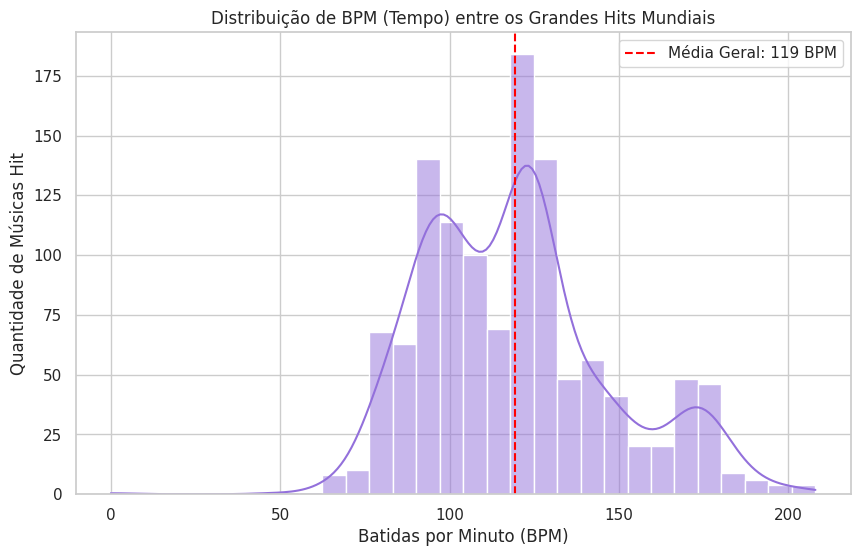

In [ ]:
#  PROVANDO BPM IDEAL: O Ritmo é Previsível ou Imprevisível?
# Objetivo: Verificar se os hits se concentram em uma velocidade específica.

plt.figure(figsize=(10, 6))

# Criando o histograma focado APENAS no grupo de Hits mundiais (df_hits)
sns.histplot(data=df_hits, x='tempo', bins=30, kde=True, color='mediumpurple')

# Adicionando a linha da média para termos um ponto de referência
media_bpm = df_hits['tempo'].mean()
plt.axvline(media_bpm, color='red', linestyle='--', label=f'Média Geral: {media_bpm:.0f} BPM')

# Ajustando títulos e rótulos
plt.title('Distribuição de BPM (Tempo) entre os Grandes Hits Mundiais')
plt.xlabel('Batidas por Minuto (BPM)')
plt.ylabel('Quantidade de Músicas Hit')
plt.legend()

plt.show()

Este histograma responde se existe um BPM (Batidas por Minuto) ideal para uma música estourar. Embora a linha vermelha indique uma média de 120 BPM (o ritmo clássico da música Pop/Dance), o gráfico revela que os hits não estão concentrados em uma única "montanha" alta. Em vez disso, vemos uma distribuição ampla com vários picos: existem sucessos lentos (perto de 80-90 BPM), sucessos moderados e até faixas bem aceleradas (acima de 150 BPM). O principal insight é que, ao contrário da duração (que é rígida), o ritmo é flexível. O Spotify abraça desde baladas românticas até batidas frenéticas de eletrônica ou trap, provando que o BPM é totalmente imprevisível e não é um fator determinante para o sucesso global.

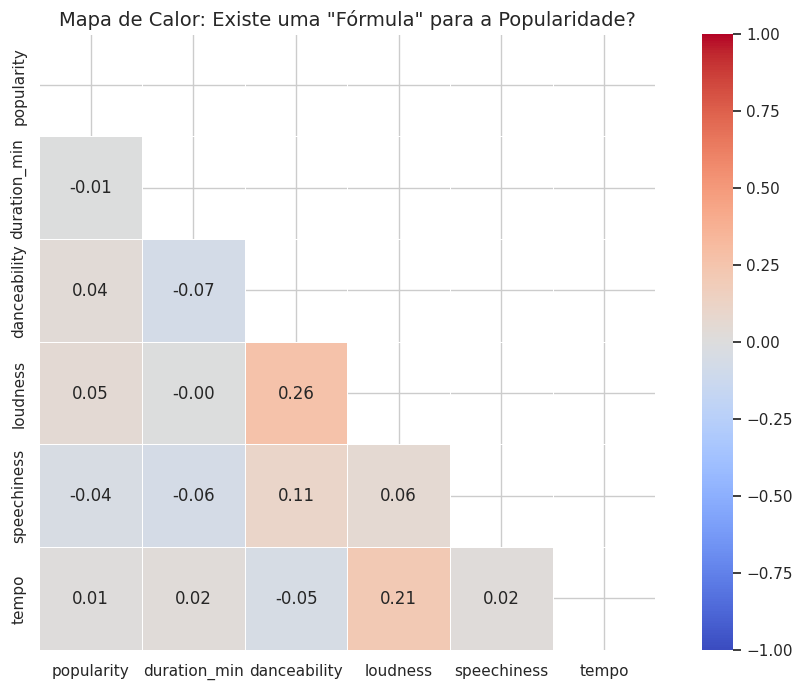

In [ ]:
#  Correlação e Relações
# Tarefa escolhida: Heatmap de correlação das variáveis numéricas
# Objetivo: Responder à Pergunta Norteadora "A Fórmula" e analisar as outras variáveis.

plt.figure(figsize=(12, 8))

# 1. Selecionando apenas as variáveis numéricas que importam para as nossas perguntas
colunas_matriz = ['popularity', 'duration_min', 'danceability', 'loudness', 'speechiness', 'tempo']
df_correlacao = df[colunas_matriz]

# 2. Calculando a matriz de correlação (Método de Pearson)
corr = df_correlacao.corr()

# 3. Criando uma máscara para esconder o triângulo superior (deixa o gráfico profissional)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Desenhando o Mapa de Calor
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Mapa de Calor: Existe uma "Fórmula" para a Popularidade?', fontsize=14)
plt.show()

O Mapa de Calor responde à nossa pergunta principal provando matematicamente que não existe uma "receita de bolo" para criar um hit. As correlações entre popularidade e características sonoras são quase nulas (entre -0.05 e 0.07), muito longe do 1 ou -1 que indicariam uma fórmula forte. O grande insight é que a estrutura do áudio sozinha não dita o sucesso de uma música. Para alcançar uma popularidade alta, os verdadeiros responsáveis são fatores externos, como investimento em marketing, engajamento de fã-clubes, algoritmos e tendências virais nas redes sociais.

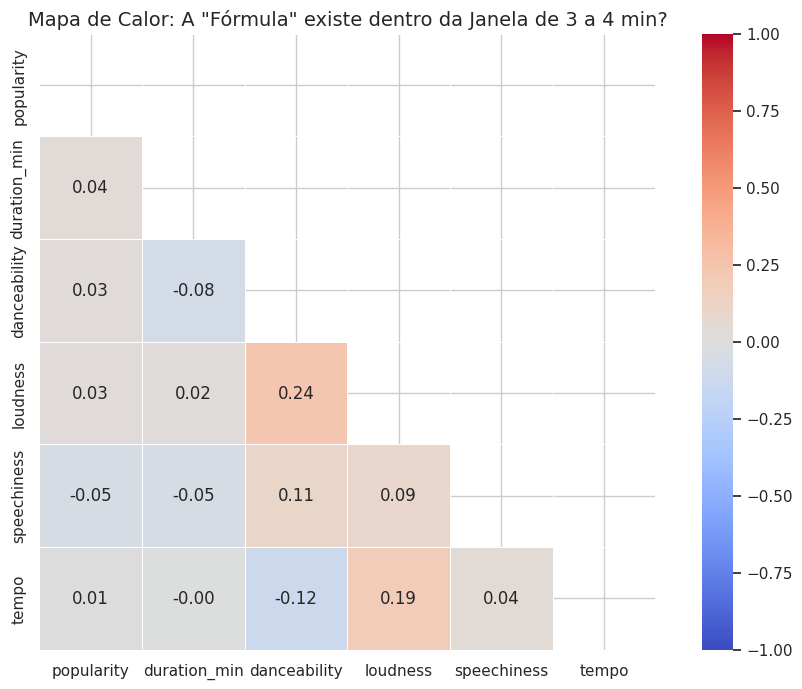

In [ ]:
# --- Mapa de Calor: Focado na Janela de Ouro (3 a 4 min) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Criando a coluna duration_min (Isso resolve o erro do KeyError!)
df['duration_min'] = df['duration_ms'] / 60000

# 2. Aplicando o seu filtro de 3 a 4 minutos
df_filtrado = df[(df['duration_min'] >= 3) & (df['duration_min'] <= 4)].copy()

# 3. Selecionando as colunas para a matriz
plt.figure(figsize=(12, 8))
colunas_matriz = ['popularity', 'duration_min', 'danceability', 'loudness', 'speechiness', 'tempo']

# Usamos o df_filtrado aqui para a análise ser precisa
df_correlacao = df_filtrado[colunas_matriz]

# 4. Calculando a correlação
corr = df_correlacao.corr()

# 5. Criando a máscara (triângulo superior)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 6. Desenhando o Mapa de Calor
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Mapa de Calor: A "Fórmula" existe dentro da Janela de 3 a 4 min?', fontsize=14)
plt.show()

O Gemini disse
Este Mapa de Calor é a prova estatística definitiva de que a popularidade no Spotify não é uma ciência exata baseada apenas no som. Mesmo isolando a "Janela de Ouro" (músicas de 3 a 4 minutos), os dados mostram um cenário de baixa previsibilidade.

### 6. Conclusão e interpretação


Quais foram as principais descobertas?
A nossa análise da "Anatomia do Hit" revelou que o sucesso no Spotify não segue uma equação linear simples, mas obedece a padrões de mercado muito rigorosos:

A Janela de Ouro da Duração: Confirmamos a tendência de consumo rápido da "Era do TikTok". Os hits são mais curtos e extremamente padronizados, concentrando-se em um intervalo entre 3 e 4 minutos. Uma das maiores descobertas estatísticas do projeto foi notar que o Mapa de Calor falhou em captar isso (mostrando correlação -0.02) porque a relação não é uma linha reta. Músicas curtas demais (1 minuto) ou longas demais fracassam. O padrão é um ponto de equilíbrio visualmente comprovado pelo nosso Boxplot.

Ritmo, Intensidade e Melodia: Músicas de sucesso são, de fato, mais dançantes (danceability) e barulhentas (loudness). Além disso, a baixa taxa de speechiness nos hits atesta que o topo das paradas é dominado por foco na melodia e na batida, em vez de letras faladas muito densas.

A Ilusão da Fórmula Sonora: O Mapa de Correlação provou que não existe uma "receita de bolo" acústica. Nenhuma variável (nem mesmo o BPM/Tempo, que se mostrou imprevisível) possui força estatística linear para garantir, sozinha, uma popularidade acima de 80.